In [ ]:
pip install kaggle

In [ ]:
from google.colab import files  # If you're using Colab
uploaded = files.upload()

Saving Train.csv to Train (1).csv


In [1]:
from google.colab import files
uploaded = files.upload()

Saving Train.csv to Train.csv


In [2]:
import pandas as pd
df = pd.read_csv("Train.csv")

In [ ]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
df.tail()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0
10998,10999,D,Ship,2,5,155,5,low,F,6,1639,0


In [ ]:

df.shape                # Rows and columns


(10999, 12)

In [ ]:
df.columns              # List of column names


Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [ ]:
df.info()               # Data types and non-null counts


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [ ]:
df.describe()           # Summary statistics for numeric columns

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [ ]:
df.isnull().sum()

,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


In [ ]:
print(df.columns.tolist())

['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.isnull().sum()

,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


In [ ]:
df_Customer_rating = df[df['Customer_rating'] < 3].count()  # e.g., more than 60 minutes
print(df_Customer_rating)

ID                     4400
Warehouse_block        4400
Mode_of_Shipment       4400
Customer_care_calls    4400
Customer_rating        4400
Cost_of_the_Product    4400
Prior_purchases        4400
Product_importance     4400
Gender                 4400
Discount_offered       4400
Weight_in_gms          4400
Reached.on.Time_Y.N    4400
dtype: int64


In [ ]:
df.groupby('Customer_rating')['Cost_of_the_Product'].min()


,Cost_of_the_Product
Customer_rating,
1,96
2,96
3,96
4,97
5,98


In [ ]:
# 1. Created a new column: Price after discount
df['Price_after_discount'] = df['Cost_of_the_Product'] * (1 - df['Discount_offered']/100)
print("Added 'Price_after_discount' column.")

Added 'Price_after_discount' column.


In [ ]:
Price_after_discount = df['Price_after_discount']
print(Price_after_discount)

0         99.12
1         88.56
2         95.16
3        158.40
4         99.36
          ...  
10994    249.48
10995    218.08
10996    232.32
10997    218.54
10998    145.70
Name: Price_after_discount, Length: 10999, dtype: float64


In [ ]:
# 2.Count the number of unique categories/values in the 'Mode_of_Shipment' column
unique_modes = df['Mode_of_Shipment'].nunique()
print(f"Unique Mode_of_Shipment values: {unique_modes}")

Unique Mode_of_Shipment values: 3


In [ ]:
# 3.Find out all the different shipment modes we have in the dataset
unique_modes_list = df['Mode_of_Shipment'].unique()

# Print the list of these shipment modes so we know exactly what categories are present
print("Unique Mode_of_Shipment values:", unique_modes_list)


Unique Mode_of_Shipment values: ['Flight' 'Ship' 'Road']


In [ ]:
# 4.Count how many different warehouse blocks are present in the data
unique_warehouse_blocks = df['Warehouse_block'].nunique()

# Print the total number of unique warehouse blocks
print("Number of unique Warehouse_block categories:", unique_warehouse_blocks)

unique_warehouse_blocks_list = df['Warehouse_block'].unique()

# Print the list of these warehouse blocks so we know exactly what categories are present
print("Unique Warehouse_block values:", unique_warehouse_blocks_list)

Number of unique Warehouse_block categories: 5
Unique Warehouse_block values: ['D' 'F' 'A' 'B' 'C']


In [ ]:
# 5. Count how many times each category appears in 'Product_importance'
print("\nValue counts for Product_importance:")
print(df['Product_importance'].value_counts())


Value counts for Product_importance:
Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64


In [ ]:
# 6. Find the average number of 'Customer_care_calls' for each 'Gender'
avg_calls_by_gender = df.groupby('Gender')['Customer_care_calls'].mean()
print("\nAverage Customer care calls by Gender:")
print(avg_calls_by_gender)



Average Customer care calls by Gender:
Gender
F    4.051578
M    4.057389
Name: Customer_care_calls, dtype: float64


In [ ]:
# 7. Check if there are any duplicate rows in the dataset
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")


Number of duplicate rows: 0


In [ ]:
df.columns


Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N', 'Price_after_discount'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    10999 non-null  int64  
 1   Warehouse_block       10999 non-null  object 
 2   Mode_of_Shipment      10999 non-null  object 
 3   Customer_care_calls   10999 non-null  int64  
 4   Customer_rating       10999 non-null  int64  
 5   Cost_of_the_Product   10999 non-null  int64  
 6   Prior_purchases       10999 non-null  int64  
 7   Product_importance    10999 non-null  object 
 8   Gender                10999 non-null  object 
 9   Discount_offered      10999 non-null  int64  
 10  Weight_in_gms         10999 non-null  int64  
 11  Reached.on.Time_Y.N   10999 non-null  int64  
 12  Price_after_discount  10999 non-null  float64
dtypes: float64(1), int64(8), object(4)
memory usage: 1.1+ MB


In [ ]:
df.shape

(10999, 13)

In [ ]:
 #8.I want to add a new column called 'Date' to the dataset.
# Since each row represents a shipment, I'm assigning one date per shipment.
# Now, I'm creating a date range starting from January 1, 2024.
# I’m using pd.date_range to generate one date per row in the DataFrame (10,999 total).
df['Date'] = pd.date_range(start='2024-01-01', periods=len(df), freq='D')

# This adds a 'Date' column where each shipment is assigned a sequential date.
# Now I’ll print the first few rows just to make sure the dates were added correctly.
print(df[['ID', 'Date']].head())


   ID       Date
0   1 2024-01-01
1   2 2024-01-02
2   3 2024-01-03
3   4 2024-01-04
4   5 2024-01-05


In [ ]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N', 'Price_after_discount', 'Date'],
      dtype='object')

In [ ]:
df.dtypes

,0
ID,int64
Warehouse_block,object
Mode_of_Shipment,object
Customer_care_calls,int64
Customer_rating,int64
Cost_of_the_Product,int64
Prior_purchases,int64
Product_importance,object
Gender,object
Discount_offered,int64


In [ ]:
# 9.I want to check how many shipments reached on time or not, based on each Mode_of_Shipment.

# So, I group the data by 'Mode_of_Shipment' and count the values of 'Reached.on.Time_Y.N' for each group.
on_time_counts = df.groupby('Mode_of_Shipment')['Reached.on.Time_Y.N'].value_counts()

# Now, I print the counts to see which shipment mode delivers on time more often.
print(on_time_counts)


Mode_of_Shipment  Reached.on.Time_Y.N
Flight            1                      1069
                  0                       708
Road              1                      1035
                  0                       725
Ship              1                      4459
                  0                      3003
Name: count, dtype: int64


In [ ]:
# 10.I want to make the 'Reached.on.Time_Y.N' column easier to understand.
# So, I will replace 1 with 'On Time' and 0 with 'Delayed'.

df['Reached.on.Time_Y.N'] = df['Reached.on.Time_Y.N'].replace({1: 'On Time', 0: 'Delayed'})

# Now, let's check the unique values in the column to confirm the change.
print(df['Reached.on.Time_Y.N'].unique())


['On Time' 'Delayed']


In [ ]:
print(df['Reached.on.Time_Y.N'])

0        On Time
1        On Time
2        On Time
3        On Time
4        On Time
          ...   
10994    On Time
10995    Delayed
10996    Delayed
10997    Delayed
10998    Delayed
Name: Reached.on.Time_Y.N, Length: 10999, dtype: object


In [ ]:
#lambda function
num=[1,2,3,4,5]
square=list(map(lambda x:x**2,num))
print(square)

[1, 4, 9, 16, 25]


In [ ]:
# I want to see only the shipments that were sent by Flight.
flights = df[df['Mode_of_Shipment'] == 'Flight']

# Print the first few rows to check
print(flights.head())


   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms Reached.on.Time_Y.N  Price_after_discount  \
0                44     

In [ ]:
# Get all rows where shipment mode is 'Air'
air_shipments = df.loc[df['Mode_of_Shipment'] == 'Air']

# Get specific columns for those rows
air_summary = df.loc[df['Mode_of_Shipment'] == 'Air', ['Cost_of_the_Product', 'Discount_offered']]

In [ ]:
# I'm selecting only the columns related to shipment and customer service using filter()
shipment_df = df.filter(items=['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Reached.on.Time_Y.N'])
print("Filtered Shipment Data:")
print(shipment_df)

Filtered Shipment Data:
      Warehouse_block Mode_of_Shipment  Customer_care_calls  \
0                   D           Flight                    4   
1                   F           Flight                    4   
2                   A           Flight                    2   
3                   B           Flight                    3   
4                   C           Flight                    2   
...               ...              ...                  ...   
10994               A             Ship                    4   
10995               B             Ship                    4   
10996               C             Ship                    5   
10997               F             Ship                    5   
10998               D             Ship                    2   

      Reached.on.Time_Y.N  
0                 On Time  
1                 On Time  
2                 On Time  
3                 On Time  
4                 On Time  
...                   ...  
10994             On Ti

In [ ]:
# I'm using str.contains to filter rows where Mode_of_Shipment includes the word 'Flight'
flight_shipments = df[df['Mode_of_Shipment'].str.contains('Flight')]
print("Flight Shipments:")
print(flight_shipments[['Warehouse_block', 'Mode_of_Shipment']])

Flight Shipments:
      Warehouse_block Mode_of_Shipment
0                   D           Flight
1                   F           Flight
2                   A           Flight
3                   B           Flight
4                   C           Flight
...               ...              ...
10972               C           Flight
10973               F           Flight
10974               D           Flight
10975               F           Flight
10976               A           Flight

[1777 rows x 2 columns]


In [ ]:
# I'm using isin to filter rows where Gender is 'F' or Product_importance is 'medium'
filtered_df = df[df['Gender'].isin(['F']) | df['Product_importance'].isin(['medium'])]
print("Filtered by Gender or Importance:")
print(filtered_df[['Warehouse_block', 'Gender', 'Product_importance']])

Filtered by Gender or Importance:
      Warehouse_block Gender Product_importance
0                   D      F                low
3                   B      M             medium
4                   C      F             medium
5                   F      F             medium
6                   D      F                low
...               ...    ...                ...
10994               A      F             medium
10995               B      F             medium
10996               C      F                low
10997               F      M             medium
10998               D      F                low

[7876 rows x 3 columns]


In [ ]:
# I'm using apply with a lambda function to calculate the savings by subtracting Price_after_discount from Cost_of_the_Product
df['Savings'] = df.apply(lambda x: x['Cost_of_the_Product'] - x['Price_after_discount'], axis=1)
print("Savings Calculation:")
print(df[['Warehouse_block', 'Cost_of_the_Product', 'Price_after_discount', 'Savings']])

Savings Calculation:
      Warehouse_block  Cost_of_the_Product  Price_after_discount  Savings
0                   D                  177                 99.12    77.88
1                   F                  216                 88.56   127.44
2                   A                  183                 95.16    87.84
3                   B                  176                158.40    17.60
4                   C                  184                 99.36    84.64
...               ...                  ...                   ...      ...
10994               A                  252                249.48     2.52
10995               B                  232                218.08    13.92
10996               C                  242                232.32     9.68
10997               F                  223                218.54     4.46
10998               D                  155                145.70     9.30

[10999 rows x 4 columns]


In [ ]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N', 'Price_after_discount', 'Date', 'Savings'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Cost_of_the_Product', ylabel='Count'>

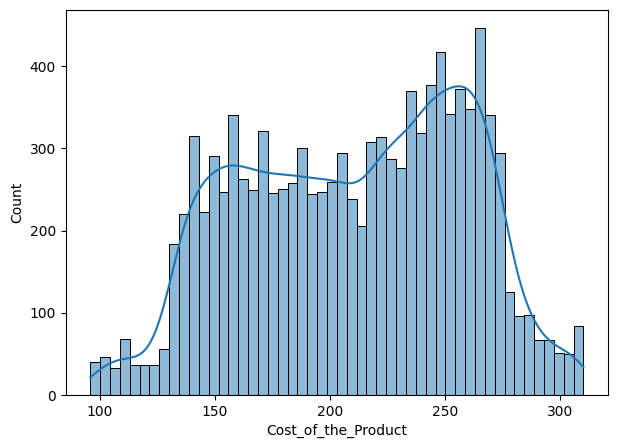

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['Cost_of_the_Product'],bins=50,kde=True)

<Axes: xlabel='Mode_of_Shipment', ylabel='count'>

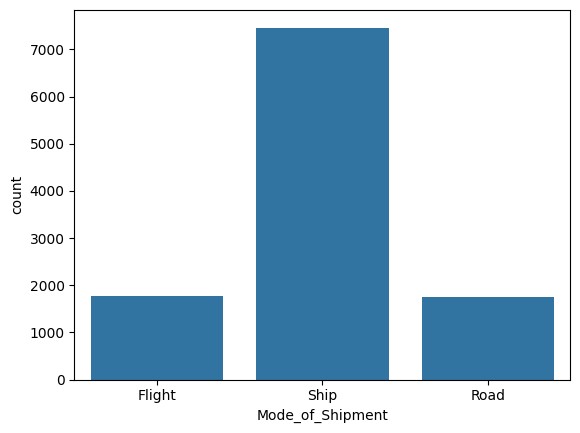

In [ ]:
sns.countplot(x='Mode_of_Shipment',data=df)

<Axes: xlabel='Cost_of_the_Product'>

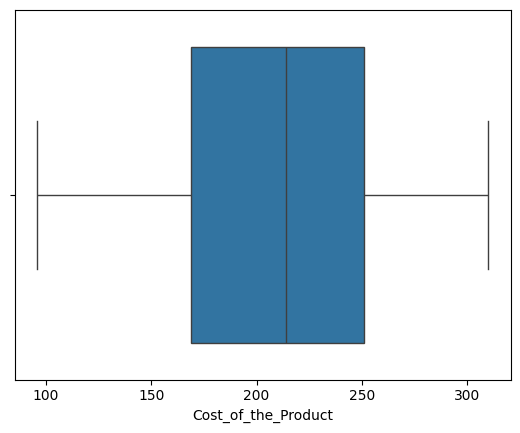

In [ ]:
sns.boxplot(x='Cost_of_the_Product',data=df)

<Axes: xlabel='Cost_of_the_Product'>

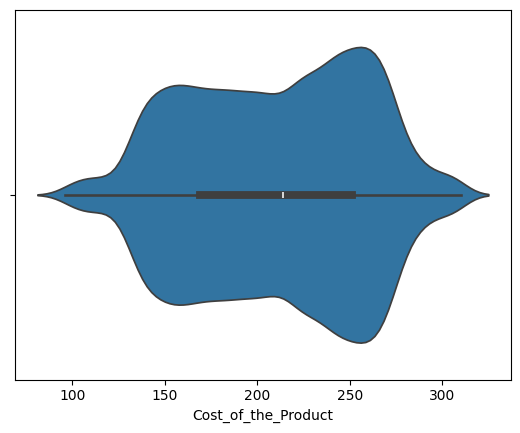

In [ ]:
sns.violinplot(x='Cost_of_the_Product',data=df)

<Axes: xlabel='Prior_purchases', ylabel='Cost_of_the_Product'>

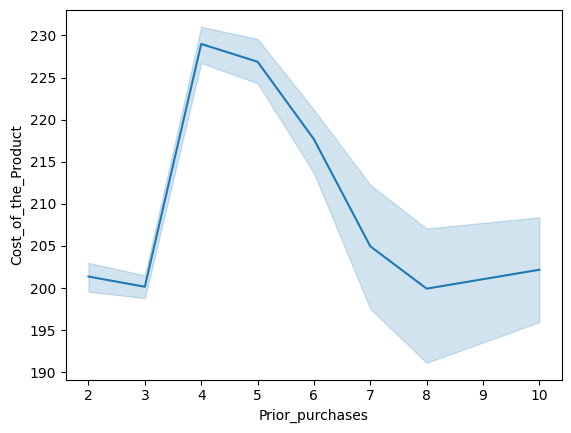

In [ ]:
sns.lineplot(x='Prior_purchases',y='Cost_of_the_Product',data=df)

<Axes: xlabel='Weight_in_gms', ylabel='Cost_of_the_Product'>

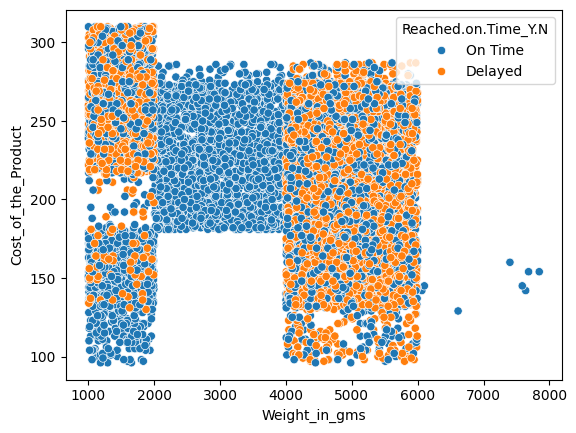

In [ ]:
sns.scatterplot(x='Weight_in_gms',y='Cost_of_the_Product',data=df,hue='Reached.on.Time_Y.N')

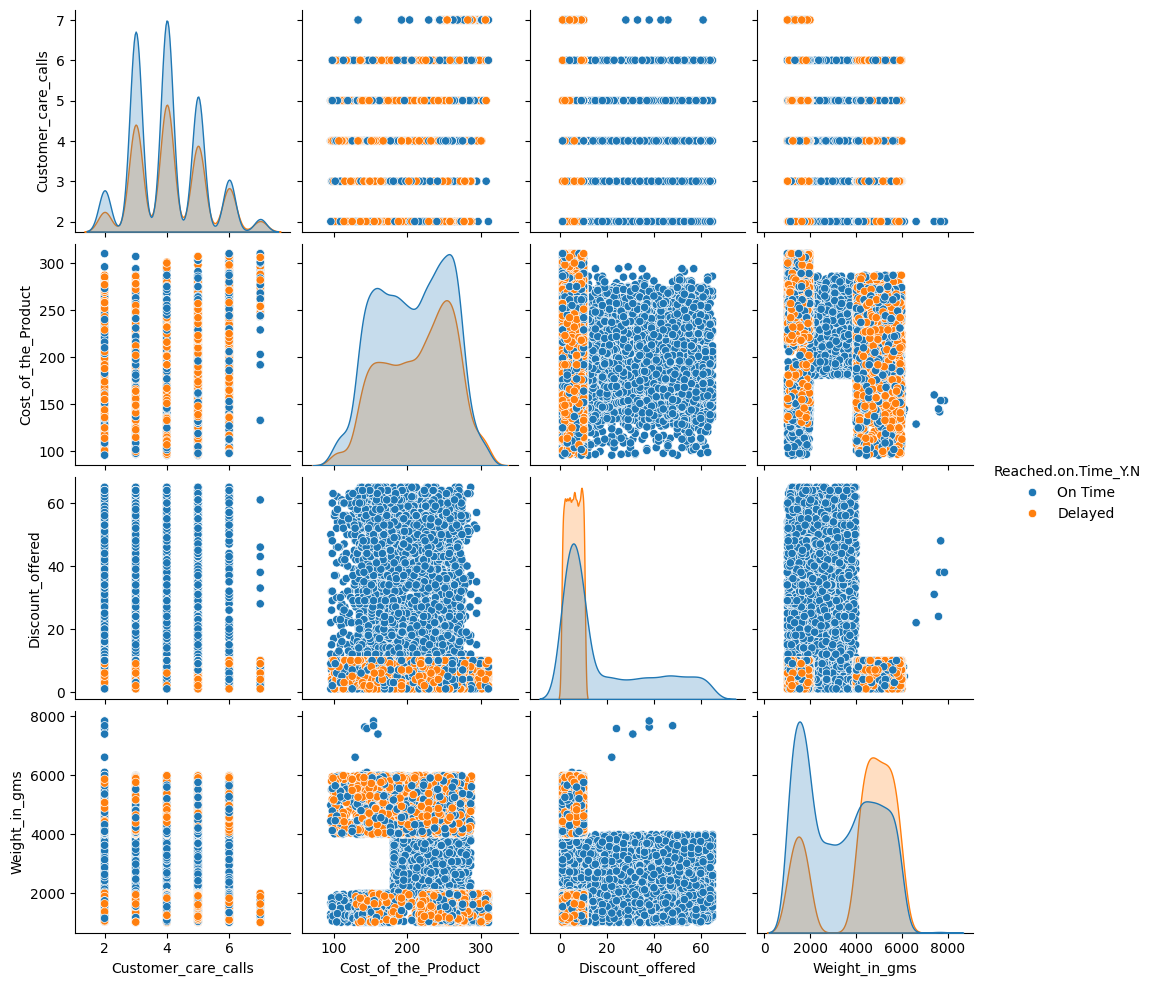

In [ ]:
num_cols=['Customer_care_calls','Cost_of_the_Product','Discount_offered','Weight_in_gms','Reached.on.Time_Y.N']
sns.pairplot(df[num_cols],
             hue= 'Reached.on.Time_Y.N')

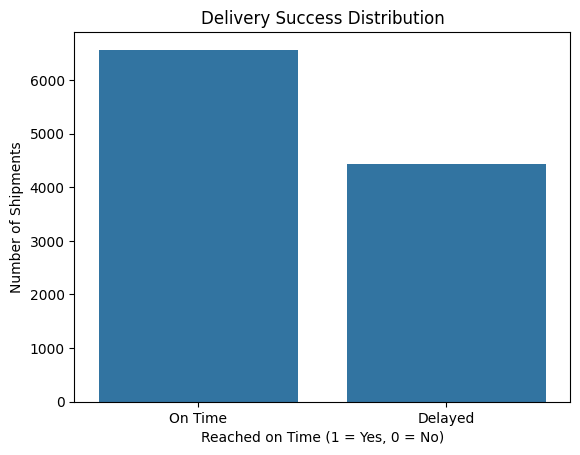

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Descriptive analytics: showing proportion of on-time vs delayed deliveries
sns.countplot(x='Reached.on.Time_Y.N', data=df)
plt.title("Delivery Success Distribution")
plt.xlabel("Reached on Time (1 = Yes, 0 = No)")
plt.ylabel("Number of Shipments")
plt.show()

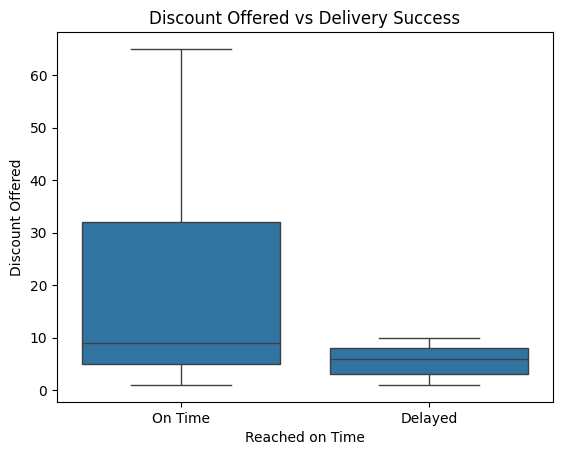

In [ ]:
# Predictive analytics: exploring relationship between discount and delivery outcome
sns.boxplot(x='Reached.on.Time_Y.N', y='Discount_offered', data=df)
plt.title("Discount Offered vs Delivery Success")
plt.xlabel("Reached on Time")
plt.ylabel("Discount Offered")
plt.show()

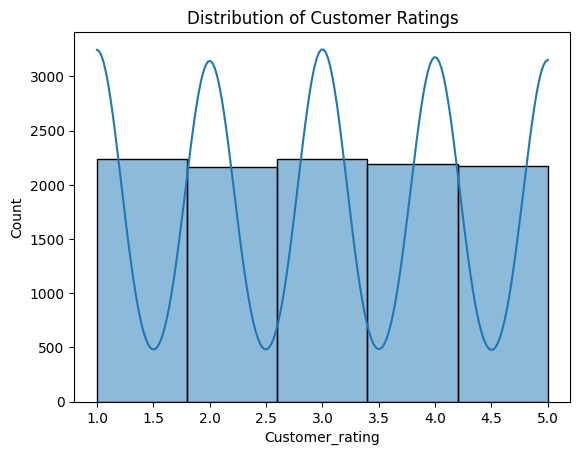

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram for Customer Rating
# This plot shows the distribution of customer ratings across the dataset.
# 'bins=5' groups ratings into 5 intervals (likely 1 to 5 stars).
# 'kde=True' adds a smooth density curve to visualize where ratings are concentrated.

sns.histplot(df['Customer_rating'], bins=5, kde=True)
plt.title('Distribution of Customer Ratings')
plt.show()



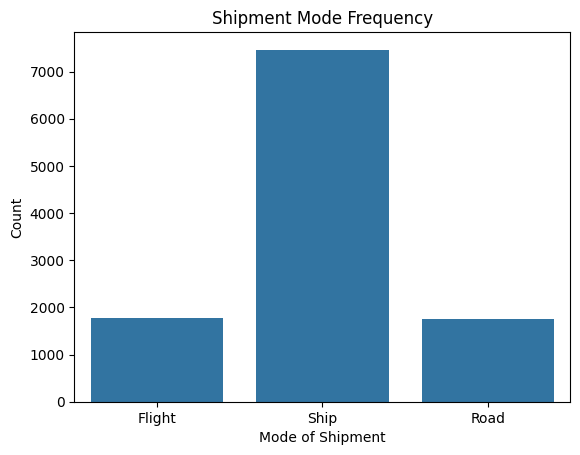

In [ ]:
# Count plot for Mode of Shipment
# Displays the frequency of each shipment method (e.g., Air, Ship, Road).
# Helps identify the most commonly used logistics channel.
sns.countplot(x='Mode_of_Shipment', data=df)
plt.title('Shipment Mode Frequency')
plt.xlabel('Mode of Shipment')
plt.ylabel('Count')
plt.show()


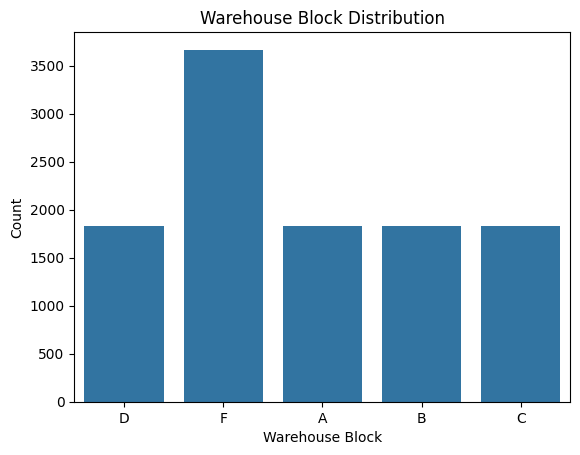

In [ ]:
# Count plot for Warehouse Block
# Shows how many orders are handled by each warehouse block.
# Useful for spotting operational load distribution.
sns.countplot(x='Warehouse_block', data=df)
plt.title('Warehouse Block Distribution')
plt.xlabel('Warehouse Block')
plt.ylabel('Count')
plt.show()


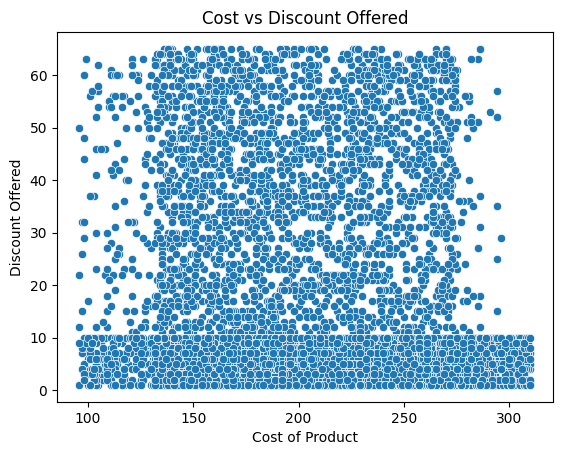

In [ ]:
# Scatter plot: Cost vs Discount Offered
# Each point represents a product.
# Helps visualize whether expensive products tend to receive higher discounts.
sns.scatterplot(x='Cost_of_the_Product', y='Discount_offered', data=df)
plt.title('Cost vs Discount Offered')
plt.xlabel('Cost of Product')
plt.ylabel('Discount Offered')
plt.show()


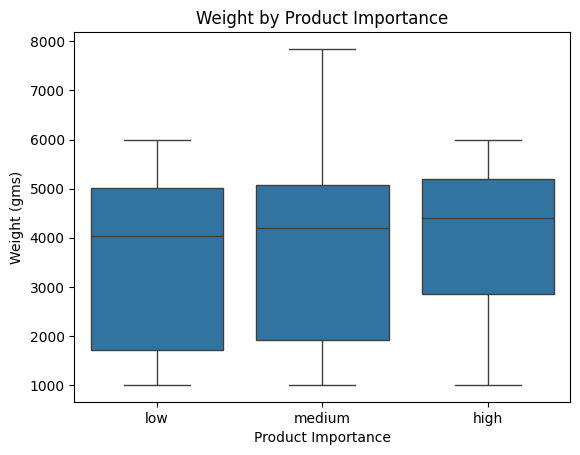

In [ ]:
# Box plot: Weight vs Product Importance
# Compares product weights across importance levels (Low, Medium, High).
# Reveals whether high-importance products are heavier.
sns.boxplot(x='Product_importance', y='Weight_in_gms', data=df)
plt.title('Weight by Product Importance')
plt.xlabel('Product Importance')
plt.ylabel('Weight (gms)')
plt.show()


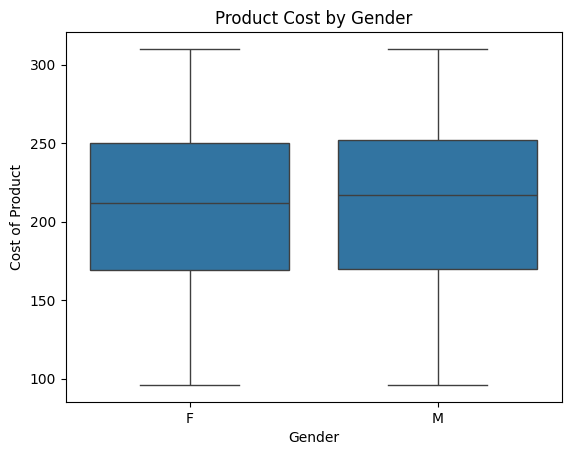

In [ ]:
# Box plot: Cost by Gender
# Compares product cost distributions between male and female customers.
# Useful for identifying spending behavior differences.
sns.boxplot(x='Gender', y='Cost_of_the_Product', data=df)
plt.title('Product Cost by Gender')
plt.xlabel('Gender')
plt.ylabel('Cost of Product')
plt.show()


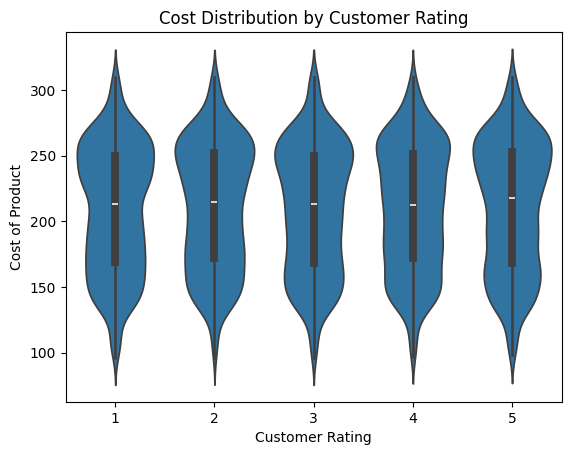

In [ ]:
# Violin plot: Cost by Customer Rating
# Shows how product cost varies with customer satisfaction.
# Useful for identifying if higher-rated products tend to be more expensive.
sns.violinplot(x='Customer_rating', y='Cost_of_the_Product', data=df)
plt.title('Cost Distribution by Customer Rating')
plt.xlabel('Customer Rating')
plt.ylabel('Cost of Product')
plt.show()


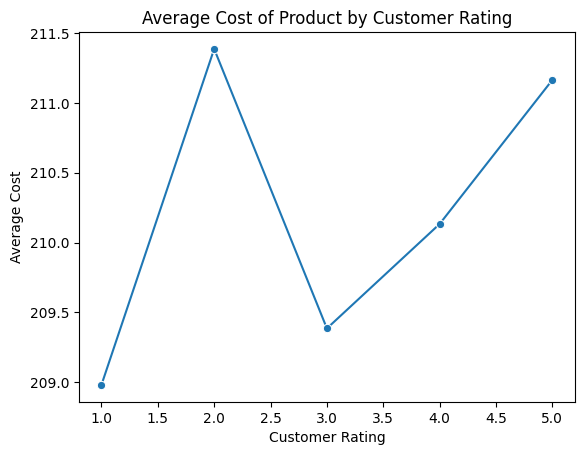

In [ ]:
# Line plot showing how the average cost of products varies across customer ratings.
# Helps identify if higher-rated products tend to be more expensive.
sns.lineplot(data=df.groupby('Customer_rating')['Cost_of_the_Product'].mean().reset_index(),
             x='Customer_rating', y='Cost_of_the_Product', marker='o')
plt.title('Average Cost of Product by Customer Rating')
plt.xlabel('Customer Rating')
plt.ylabel('Average Cost')
plt.show()

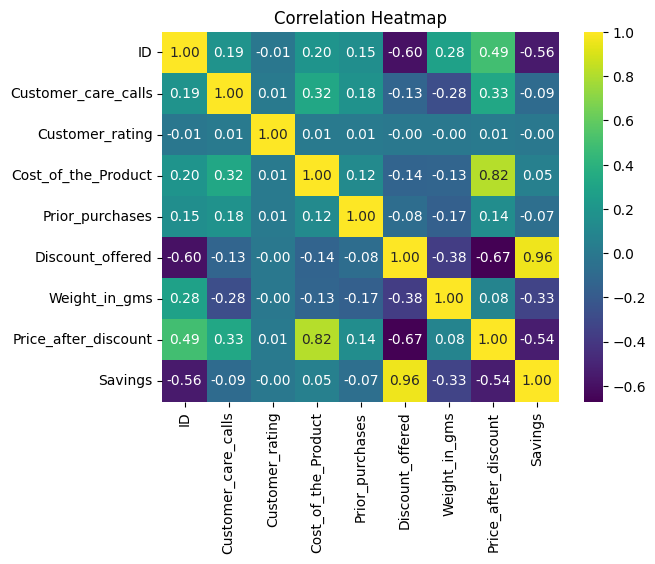

In [ ]:
# Heatmap showing correlation between numerical variables.
# Useful for identifying strong relationships (positive or negative) between features.
# Select only numeric columns before computing correlation
numeric_df = df.select_dtypes(include='number')

# Now plot the heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

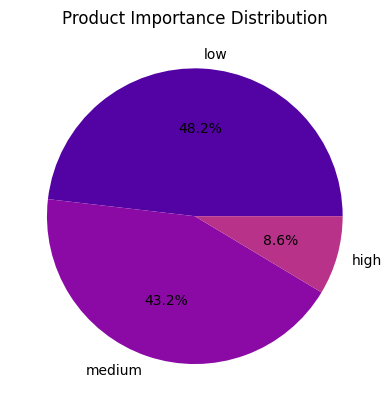

In [ ]:
# Pie chart showing the proportion of products by importance level (Low, Medium, High).
# Helps visualize how product importance is distributed across the dataset.
df['Product_importance'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('plasma'))
plt.title('Product Importance Distribution')
plt.ylabel('')
plt.show()

/tmp/ipython-input-987775066.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Gender', y='Discount_offered', jitter=True, palette='plasma')


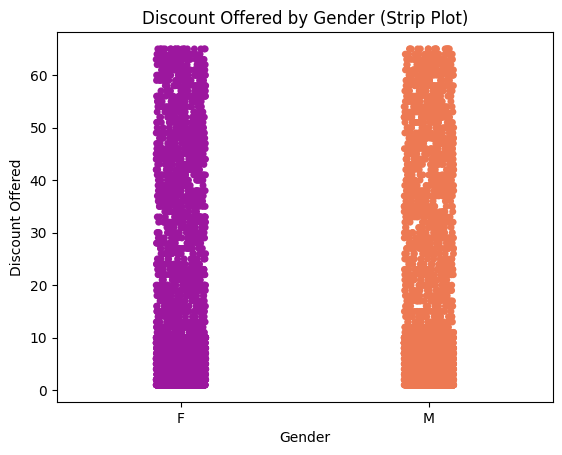

In [ ]:
# Strip plot showing discount values for each gender.
# Jitter helps separate overlapping points, making the distribution clearer.
sns.stripplot(data=df, x='Gender', y='Discount_offered', jitter=True, palette='plasma')
plt.title('Discount Offered by Gender (Strip Plot)')
plt.xlabel('Gender')
plt.ylabel('Discount Offered')
plt.show()

In [ ]:
# Applying Bayes' Theorem manually
mode_counts = df['Mode_of_Shipment'].value_counts(normalize=True)
on_time_given_mode = df[df['Reached.on.Time_Y.N'] == 1]['Mode_of_Shipment'].value_counts(normalize=True)
bayes_result = (on_time_given_mode * df['Reached.on.Time_Y.N'].mean()) / mode_counts
print("Bayes' Theorem result:\n", bayes_result)  # Bayes rule applied to shipment mode

TypeError: Could not convert string 'On TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn TimeOn T

In [ ]:
# Poisson: modeling purchase counts
from scipy.stats import poisson
mean_purchases = df['Prior_purchases'].mean()
poisson_dist = poisson.pmf(k=5, mu=mean_purchases)
print("Poisson PMF (k=5):", poisson_dist)

Poisson PMF (k=5): 0.13592834304870746


In [ ]:
# Fit normal distribution to product cost
from scipy.stats import norm
mean_cost = df['Cost_of_the_Product'].mean()
std_cost = df['Cost_of_the_Product'].std()
normal_pdf = norm.pdf(x=200, loc=mean_cost, scale=std_cost)
print("Normal PDF at x=200:", normal_pdf)

Normal PDF at x=200: 0.008115645079716155


In [ ]:
# Chi-squared from squared z-scores
import numpy as np
z_discount = (df['Discount_offered'] - df['Discount_offered'].mean()) / df['Discount_offered'].std()
chi_squared = np.square(z_discount)
print("Chi-squared values:\n", chi_squared.head())

Chi-squared values:
 0    3.571712
1    7.927083
2    4.565601
3    0.043327
4    4.053426
Name: Discount_offered, dtype: float64


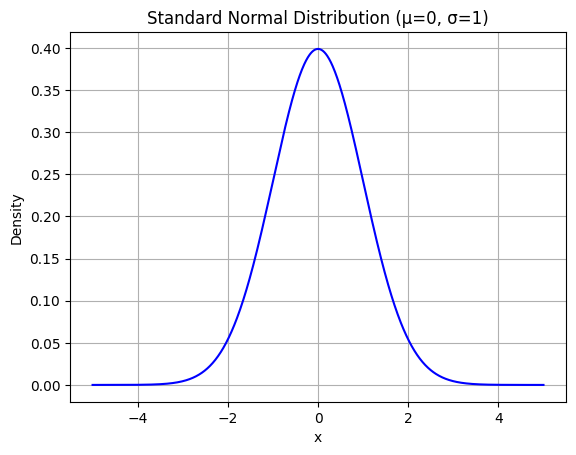

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

x = np.linspace(-5, 5, 1000)
plt.plot(x, stats.norm.pdf(x, 0, 1), color="blue")
 #Standard Normal Distribution has mean=0 and std=1
plt.title("Standard Normal Distribution (μ=0, σ=1)")
plt.xlabel("x")
plt.ylabel("Density")
plt.grid(True)
plt.show()


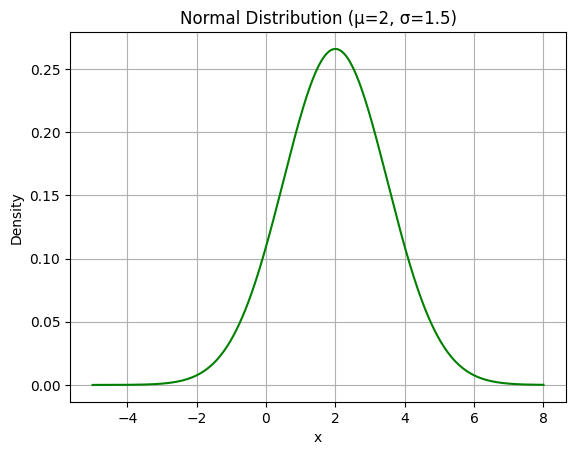

In [ ]:
# Create a range of x values from -5 to 8
x = np.linspace(-5, 8, 1000)

# Normal Distribution with mean=2, std=1.5
plt.plot(x, stats.norm.pdf(x, 2, 1.5), color="green")

plt.title("Normal Distribution (μ=2, σ=1.5)")
plt.xlabel("x")
plt.ylabel("Density")
plt.grid(True)
plt.show()


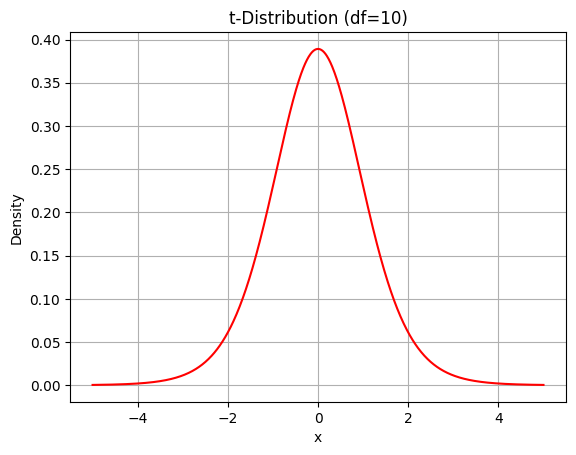

In [ ]:
# Create a range of x values from -5 to 5
x = np.linspace(-5, 5, 1000)

# t-distribution with 10 degrees of freedom
plt.plot(x, stats.t.pdf(x, df=10), color="red")

plt.title("t-Distribution (df=10)")
plt.xlabel("x")
plt.ylabel("Density")
plt.grid(True)
plt.show()


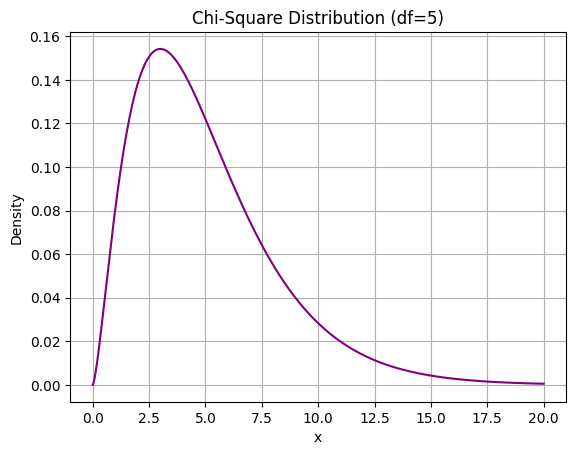

In [ ]:
# Create a range of x values from 0 to 20
x = np.linspace(0, 20, 1000)

# Chi-Square distribution with 5 degrees of freedom
plt.plot(x, stats.chi2.pdf(x, df=5), color="purple")

plt.title("Chi-Square Distribution (df=5)")
plt.xlabel("x")
plt.ylabel("Density")
plt.grid(True)
plt.show()


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

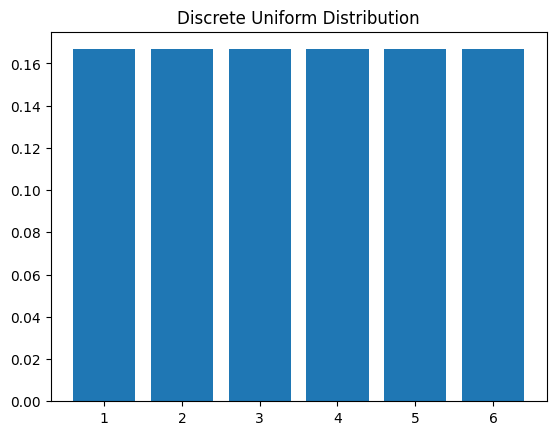

In [6]:
#PROBABILITY DISTRIBUTIONS
from scipy.stats import randint
x = np.arange(1, 7)
pmf_uniform = [1/6] * 6
plt.bar(x, pmf_uniform)
plt.title("Discrete Uniform Distribution")
plt.show()

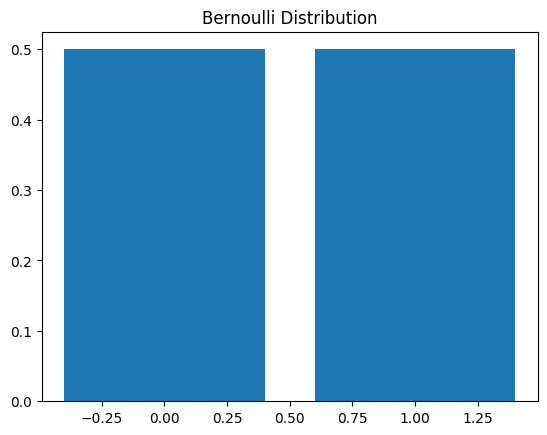

In [7]:
from scipy.stats import bernoulli
p = 0.5
x = [0, 1]
pmf_bernoulli = bernoulli.pmf(x, p)
plt.bar(x, pmf_bernoulli)
plt.title("Bernoulli Distribution")
plt.show()


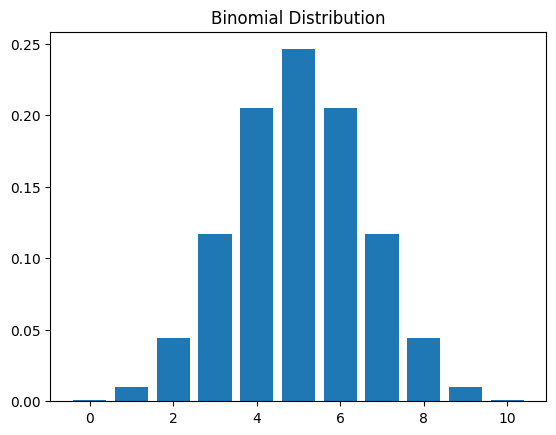

In [8]:
from scipy.stats import binom
n, p = 10, 0.5
x = np.arange(0, n+1)
pmf_binomial = binom.pmf(x, n, p)
plt.bar(x, pmf_binomial)
plt.title("Binomial Distribution")
plt.show()


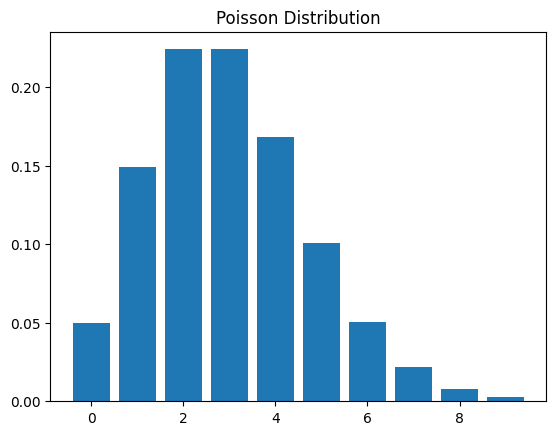

In [9]:
from scipy.stats import poisson
mu = 3
x = np.arange(0, 10)
pmf_poisson = poisson.pmf(x, mu)
plt.bar(x, pmf_poisson)
plt.title("Poisson Distribution")
plt.show()


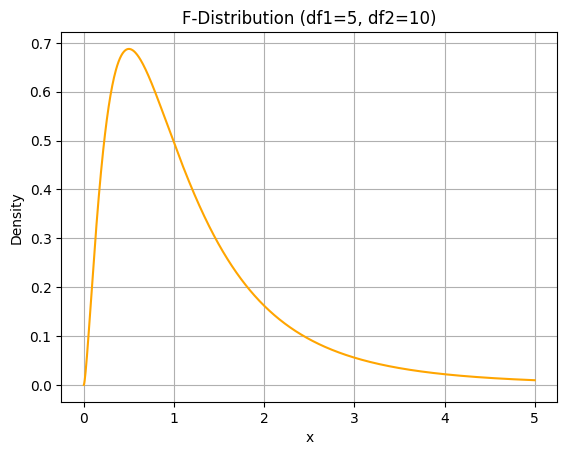

In [ ]:
# Create a range of x values from 0 to 5
x = np.linspace(0, 5, 1000)

# F-distribution with numerator df=5, denominator df=10
plt.plot(x, stats.f.pdf(x, dfn=5, dfd=10), color="orange")

plt.title("F-Distribution (df1=5, df2=10)")
plt.xlabel("x")
plt.ylabel("Density")
plt.grid(True)
plt.show()


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB
None

Shape of Dataset: (10999, 12)

Columns: ['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Co

/tmp/ipython-input-2216792093.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Reached.on.Time_Y.N', data=df, palette='viridis')


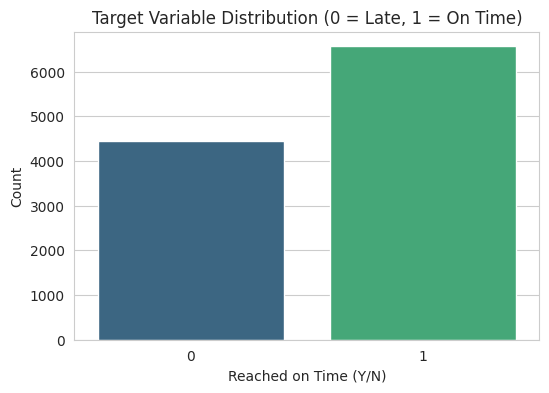

/tmp/ipython-input-2216792093.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


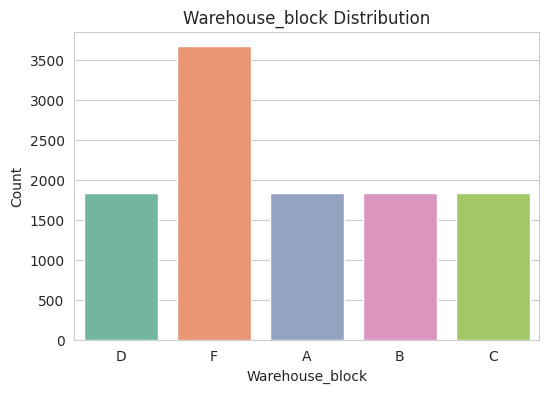

/tmp/ipython-input-2216792093.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


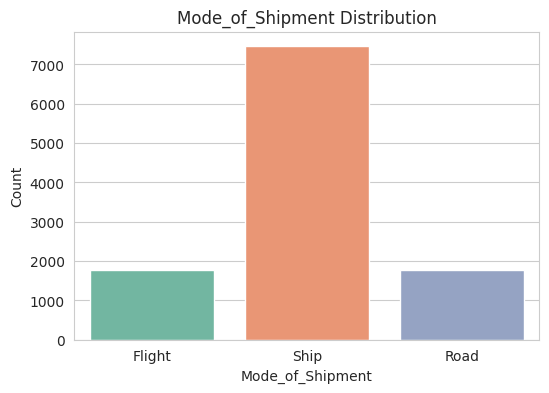

/tmp/ipython-input-2216792093.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


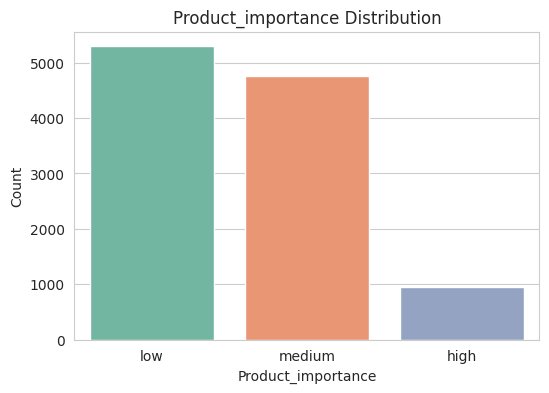

/tmp/ipython-input-2216792093.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


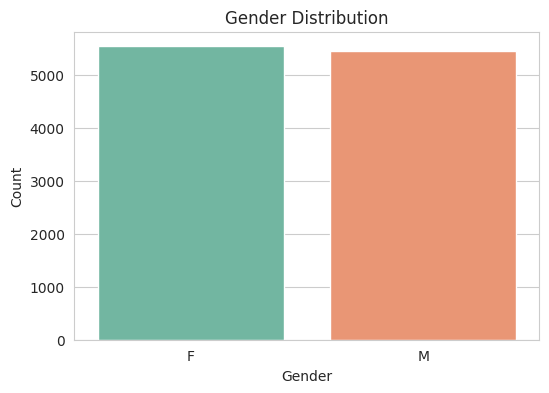

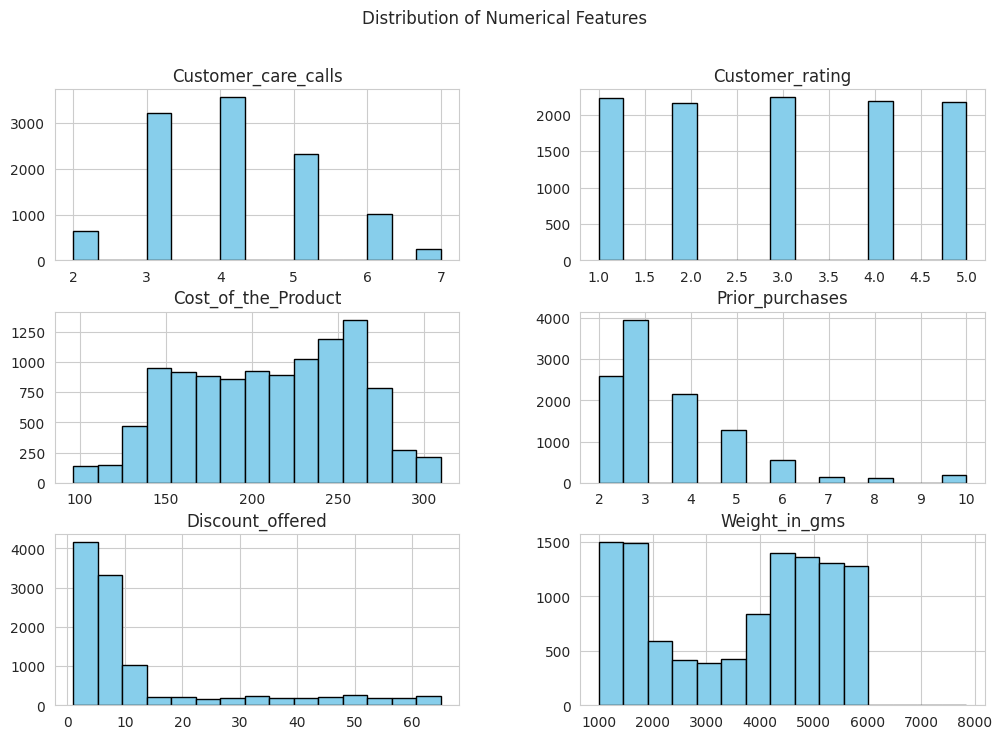

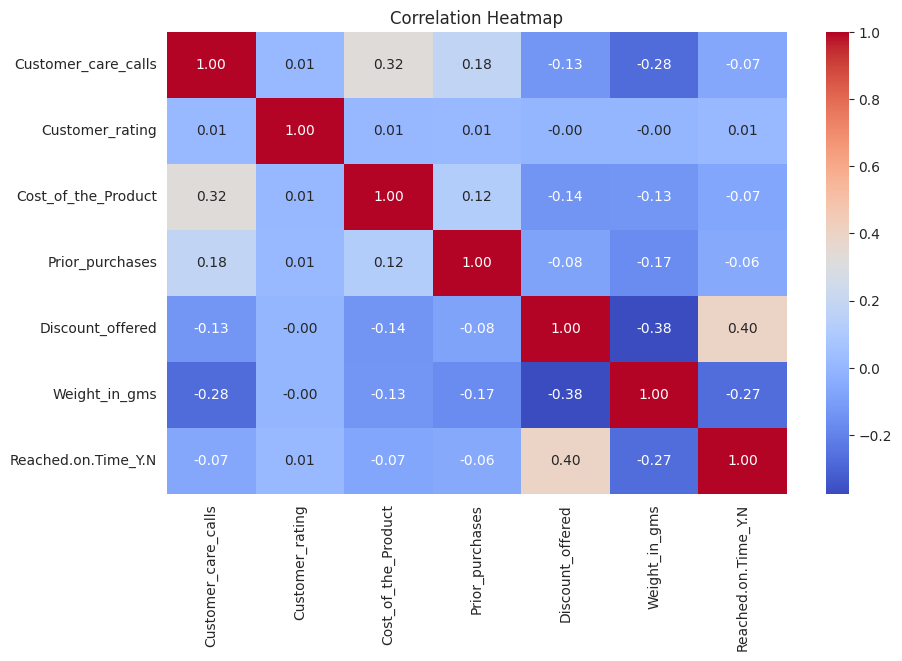

/tmp/ipython-input-2216792093.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Reached.on.Time_Y.N', y=col, data=df, palette='coolwarm')


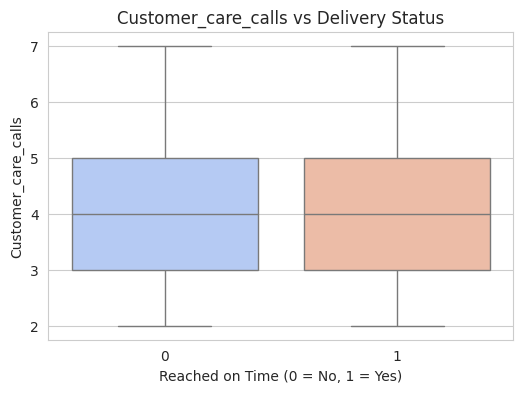

/tmp/ipython-input-2216792093.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Reached.on.Time_Y.N', y=col, data=df, palette='coolwarm')


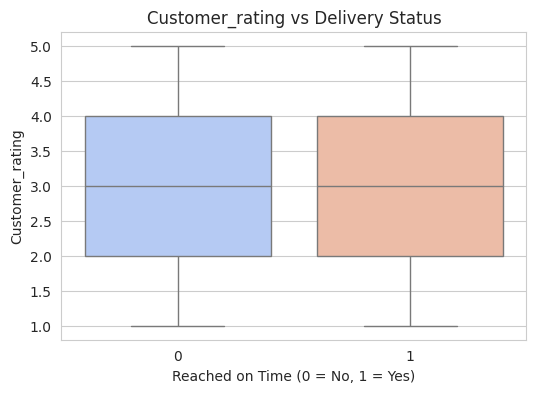

/tmp/ipython-input-2216792093.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Reached.on.Time_Y.N', y=col, data=df, palette='coolwarm')


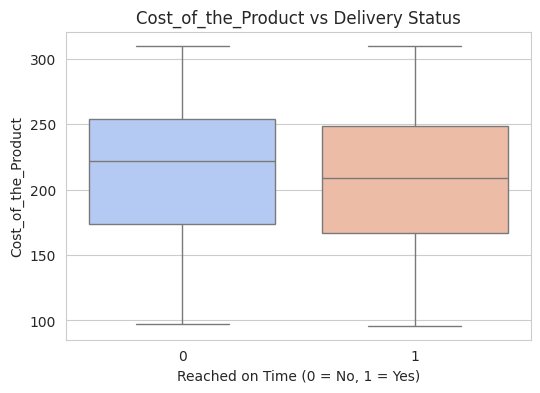

/tmp/ipython-input-2216792093.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Reached.on.Time_Y.N', y=col, data=df, palette='coolwarm')


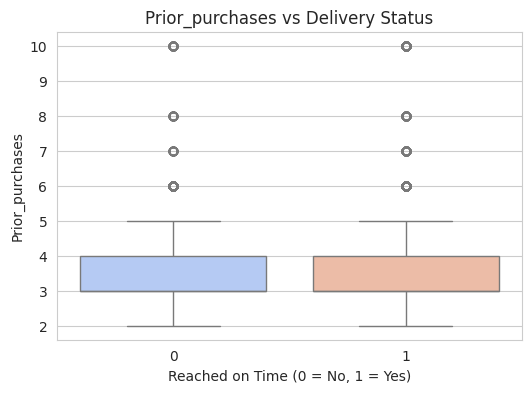

/tmp/ipython-input-2216792093.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Reached.on.Time_Y.N', y=col, data=df, palette='coolwarm')


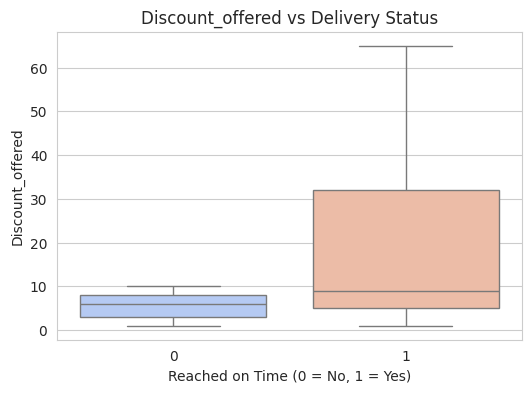

/tmp/ipython-input-2216792093.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Reached.on.Time_Y.N', y=col, data=df, palette='coolwarm')


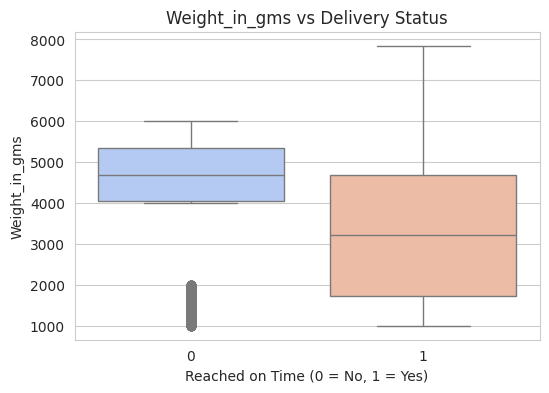

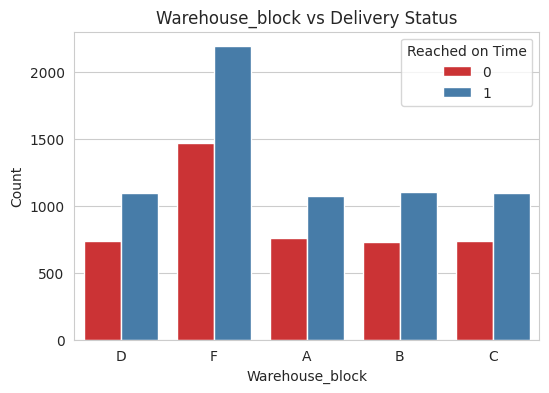

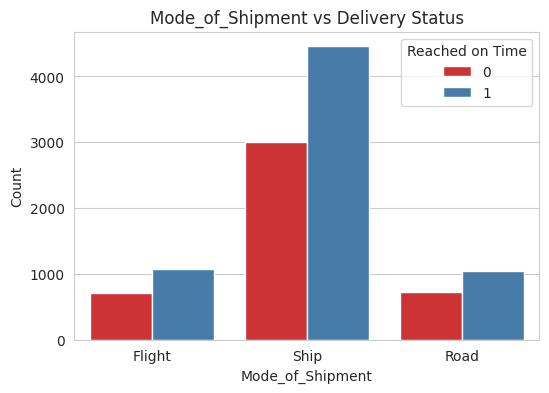

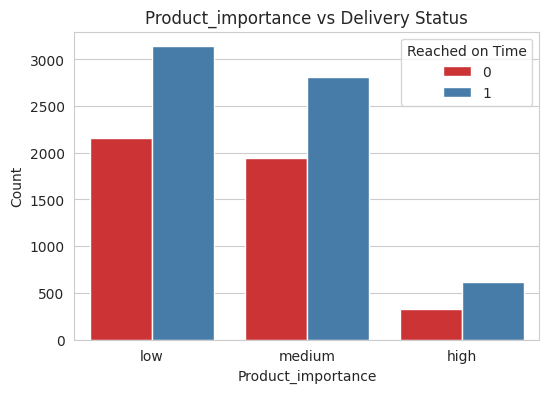

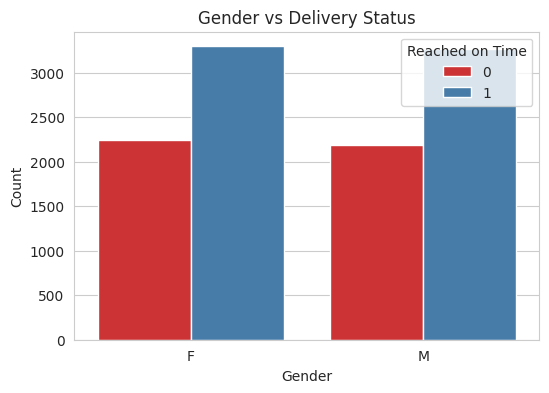

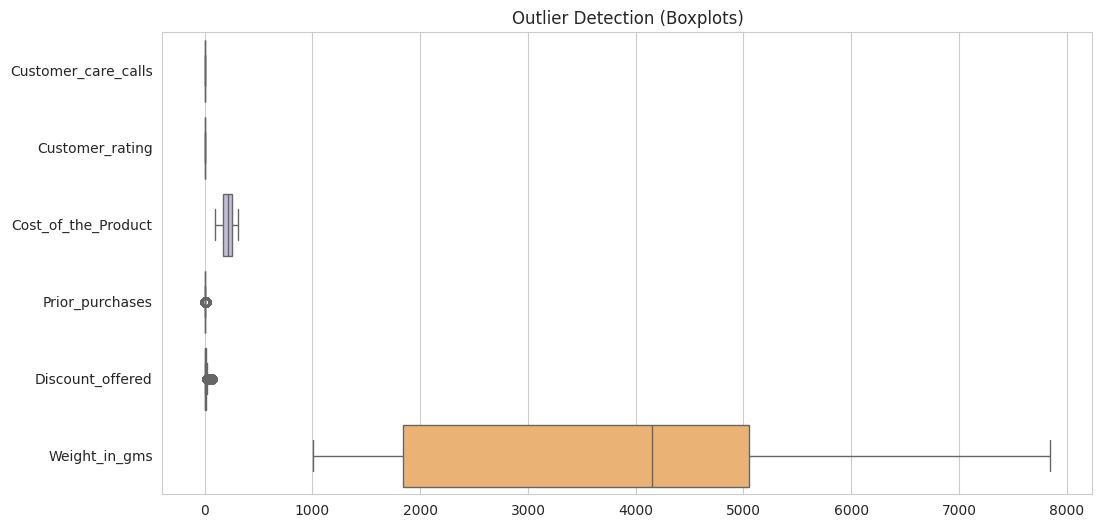

In [23]:
# EXPLORATORY DATA ANALYSIS (EDA)
# Step 1: Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load dataset
df = pd.read_csv('Train.csv')  # Replace with your actual file path

# Step 3: Basic info about the dataset
print("Dataset Overview:")
print(df.info())

print("\nShape of Dataset:", df.shape)
print("\nColumns:", df.columns.tolist())

# Step 4: Summary statistics
print("\nStatistical Summary:")
print(df.describe())

# Step 5: Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Step 6: Check for duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Step 7: Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Reached.on.Time_Y.N', data=df, palette='viridis')
plt.title('Target Variable Distribution (0 = Late, 1 = On Time)')
plt.xlabel('Reached on Time (Y/N)')
plt.ylabel('Count')
plt.show()

# Step 8: Categorical features distribution
categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df, palette='Set2')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# Step 9: Numerical features distribution
numeric_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
                'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

df[numeric_cols].hist(figsize=(12, 8), bins=15, color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features')
plt.show()

# Step 10: Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols + ['Reached.on.Time_Y.N']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Step 11: Relationship between numerical features & target
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Reached.on.Time_Y.N', y=col, data=df, palette='coolwarm')
    plt.title(f'{col} vs Delivery Status')
    plt.xlabel('Reached on Time (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.show()

# Step 12: Categorical vs Target variable
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue='Reached.on.Time_Y.N', data=df, palette='Set1')
    plt.title(f'{col} vs Delivery Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Reached on Time', loc='upper right')
    plt.show()

# Step 13: Check outliers (using boxplots)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols], orient="h", palette="Set3")
plt.title("Outlier Detection (Boxplots)")
plt.show()


In [ ]:
# Mean Imputation
mean_imputation = df.fillna(df.mean(numeric_only=True))

# Median Imputation
median_imputation = df.fillna(df.median(numeric_only=True))

# Mode Imputation (first mode for each column)
mode_imputation = df.fillna(df.mode().iloc[0])

# Forward Fill
forward_fill = df.fillna(method='ffill')

# Backward Fill
backward_fill = df.fillna(method='bfill')
print("\nImputation using Mean:")
print(mean_imputation)

print("\nImputation using Median:")
print(median_imputation)

print("\nImputation using Mode:")
print(mode_imputation)

print("\nForward Fill:")
print(forward_fill)

print("\nBackward Fill:")
print(backward_fill)




Imputation using Mean:
          ID Warehouse_block Mode_of_Shipment  Customer_care_calls  \
0          1               D           Flight                    4   
1          2               F           Flight                    4   
2          3               A           Flight                    2   
3          4               B           Flight                    3   
4          5               C           Flight                    2   
...      ...             ...              ...                  ...   
10994  10995               A             Ship                    4   
10995  10996               B             Ship                    4   
10996  10997               C             Ship                    5   
10997  10998               F             Ship                    5   
10998  10999               D             Ship                    2   

       Customer_rating  Cost_of_the_Product  Prior_purchases  \
0                    2                  177                3   
1      

/tmp/ipython-input-3864270776.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  forward_fill = df.fillna(method='ffill')
/tmp/ipython-input-3864270776.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  backward_fill = df.fillna(method='bfill')


In [ ]:


# Feature 1: Total_Shipment_Cost
# The total cost of shipping for a product might depend on various factors, like the product cost, weight, and discount offered.
# This new feature combines them to give an estimate of the cost the company incurs to ship a product.
df['Total_Shipment_Cost'] = df['Cost_of_the_Product'] + (df['Weight_in_gms'] * 0.05) - df['Discount_offered']
print(df[['ID', 'Total_Shipment_Cost']])




          ID  Total_Shipment_Cost
0          1               194.65
1          2               311.40
2          3               303.70
3          4               224.85
4          5               262.20
...      ...                  ...
10994  10995               327.90
10995  10996               288.35
10996  10997               295.75
10997  10998               281.50
10998  10999               230.95

[10999 rows x 2 columns]


In [ ]:
# Feature 2: Customer_Loyalty_Score
# A simple loyalty score based on prior purchases and customer rating, assuming more purchases and higher ratings show loyalty.
df['Customer_Loyalty_Score'] = df['Prior_purchases'] * df['Customer_rating'] / 10
print(df[['ID', 'Customer_Loyalty_Score']])


          ID  Customer_Loyalty_Score
0          1                     0.6
1          2                     1.0
2          3                     0.8
3          4                     1.2
4          5                     0.6
...      ...                     ...
10994  10995                     0.5
10995  10996                     0.5
10996  10997                     2.0
10997  10998                     1.2
10998  10999                     2.5

[10999 rows x 2 columns]


In [ ]:
# Feature 3: Shipment_Priority
# A feature that gives the product higher priority based on its importance and customer care calls.
# More customer care calls can indicate that the product needs more attention or priority for shipment.
df['Shipment_Priority'] = df['Product_importance'].map({'High': 2, 'Medium': 1, 'Low': 0}) + df['Customer_care_calls'] * 0.1
print(df[['ID', 'Shipment_Priority']])


          ID  Shipment_Priority
0          1                NaN
1          2                NaN
2          3                NaN
3          4                NaN
4          5                NaN
...      ...                ...
10994  10995                NaN
10995  10996                NaN
10996  10997                NaN
10997  10998                NaN
10998  10999                NaN

[10999 rows x 2 columns]


In [ ]:
# Feature 4: Weight_Category
# Classifying the weight of the product into three categories: 'Light', 'Medium', 'Heavy'.
df['Weight_Category'] = pd.cut(df['Weight_in_gms'], bins=[0, 500, 1000, float('inf')], labels=['Light', 'Medium', 'Heavy'])
print(df[['ID', 'Weight_Category']])


          ID Weight_Category
0          1           Heavy
1          2           Heavy
2          3           Heavy
3          4           Heavy
4          5           Heavy
...      ...             ...
10994  10995           Heavy
10995  10996           Heavy
10996  10997           Heavy
10997  10998           Heavy
10998  10999           Heavy

[10999 rows x 2 columns]


In [ ]:
# Feature 5: Discount_to_Price_Ratio
# A ratio of the discount offered to the cost of the product, which gives insight into the level of discount relative to the product price.
df['Discount_to_Price_Ratio'] = df['Discount_offered'] / df['Cost_of_the_Product']
print(df[['ID', 'Discount_to_Price_Ratio']])


          ID  Discount_to_Price_Ratio
0          1                 0.248588
1          2                 0.273148
2          3                 0.262295
3          4                 0.056818
4          5                 0.250000
...      ...                      ...
10994  10995                 0.003968
10995  10996                 0.025862
10996  10997                 0.016529
10997  10998                 0.008969
10998  10999                 0.038710

[10999 rows x 2 columns]


In [ ]:
# Feature 6: Gender_Encoded
# Encoding the Gender column to numerical values for use in modeling.
# Assuming 1 for Male and 0 for Female, though this encoding could be adjusted if needed.
df['Gender_Encoded'] = df['Gender'].map({'Male': 1, 'Female': 0})
print(df[['ID', 'Gender_Encoded']])


          ID  Gender_Encoded
0          1             NaN
1          2             NaN
2          3             NaN
3          4             NaN
4          5             NaN
...      ...             ...
10994  10995             NaN
10995  10996             NaN
10996  10997             NaN
10997  10998             NaN
10998  10999             NaN

[10999 rows x 2 columns]


In [ ]:
# Feature 7: Customer_Experience
# Creating a customer experience score based on rating, customer care calls, and prior purchases.
# A higher rating, fewer calls, and more purchases imply better experience.
df['Customer_Experience'] = df['Customer_rating'] - (df['Customer_care_calls'] * 0.1) + (df['Prior_purchases'] * 0.05)
print(df['Customer_Experience'])


0        1.75
1        4.70
2        2.00
3        2.90
4        1.95
         ... 
10994    0.85
10995    0.85
10996    3.75
10997    1.80
10998    5.05
Name: Customer_Experience, Length: 10999, dtype: float64


In [ ]:
# Feature 8: OnTime_Shipment_Indicator
# A binary indicator if the product was delivered on time (1 for Yes, 0 for No).
df['OnTime_Shipment_Indicator'] = df['Reached.on.Time_Y.N'].map({'Y': 1, 'N': 0})
print(df['OnTime_Shipment_Indicator'])



0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
10994   NaN
10995   NaN
10996   NaN
10997   NaN
10998   NaN
Name: OnTime_Shipment_Indicator, Length: 10999, dtype: float64


In [ ]:
# Feature 9: Product_Cost_Per_Unit_Weight
# Dividing the cost of the product by its weight in grams gives an indication of how expensive the product is per unit of weight.
df['Product_Cost_Per_Unit_Weight'] = df['Cost_of_the_Product'] / df['Weight_in_gms']
print(df['Product_Cost_Per_Unit_Weight'])


0        0.143552
1        0.069948
2        0.054238
3        0.149533
4        0.074074
           ...   
10994    0.163849
10995    0.186047
10996    0.209524
10997    0.184298
10998    0.094570
Name: Product_Cost_Per_Unit_Weight, Length: 10999, dtype: float64


In [ ]:
# Feature 10: Prior_Purchases_Category
# Categorizing prior purchases into three levels: 'Low', 'Medium', and 'High'.
df['Prior_Purchases_Category'] = pd.cut(df['Prior_purchases'], bins=[0, 5, 15, float('inf')], labels=['Low', 'Medium', 'High'])
print(df['Prior_Purchases_Category'])

0           Low
1           Low
2           Low
3           Low
4           Low
          ...  
10994       Low
10995       Low
10996       Low
10997    Medium
10998       Low
Name: Prior_Purchases_Category, Length: 10999, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']




```
# This is formatted as code
```

**Logistic regression  **is a supervised machine learning algorithm used for binary classification. Instead of predicting a continuous value like linear regression, it predicts the probability that a given input belongs to a class (e.g., 0 or 1). The logistic function (sigmoid) maps any real-valued number to a value between 0 and 1.

If the probability is ≥ 0.5, the model predicts class 1; otherwise, class 0.

Accuracy: 0.88

Confusion Matrix:
 [[120  16]
 [ 20 144]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       136
           1       0.90      0.88      0.89       164

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



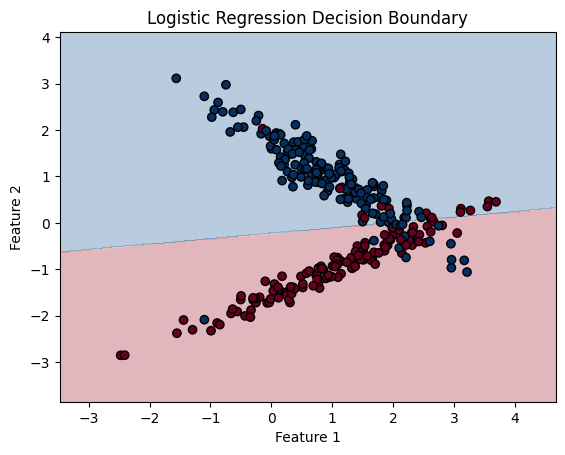

In [13]:
# Step 1: Import necessary libraries
import numpy as np                      # For numerical operations
import matplotlib.pyplot as plt         # For plotting
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.linear_model import LogisticRegression    # For classification model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # For evaluation
# Step 2: Generate synthetic classification data
# We'll create a dataset with two informative features and a binary target
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,           # Total number of samples
    n_features=2,             # Number of features (2D for easy visualization)
    n_informative=2,          # Both features are informative
    n_redundant=0,            # No redundant features
    n_clusters_per_class=1,   # One cluster per class
    flip_y=0.1,               # Add 10% label noise
    random_state=42           # For reproducibility
)

# Step 3: Split the data into training and testing sets
# This helps evaluate model performance on unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
# Step 4: Create and train the logistic regression model
# Fit the model to the training data
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 5: Make predictions on the test set
# Predict class labels for the test data
y_pred = model.predict(X_test)

# Step 6: Evaluate the model's performance
# Print accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Print confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Print detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# Step 7: Visualize the decision boundary
# This helps us understand how the model separates the two classes
def plot_decision_boundary(X, y, model):
    h = .02  # Step size for mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create a mesh grid of points
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict class labels for each point in the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.3)

    # Plot the actual data points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k')
    plt.title("Logistic Regression Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# Call the function to plot decision boundary
plot_decision_boundary(X_test, y_test, model)


In [14]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

**What Is Linear Regression?**

Linear regression is a supervised machine learning algorithm used to model the relationship between a dependent variable (target) and one or more independent variables (features). It assumes this relationship is linear, meaning it can be represented by a straight line:

y=β0​+β1​x1​+β2​x2​+⋯+βn​xn​+ε

y: predicted value (target)
x₁, x₂, ..., xₙ: input features
β₀: intercept (value of y when all x = 0)
β₁ to βₙ: coefficients (slopes showing impact of each feature)
ε: error term bold text

---



First 5 rows of the dataset:
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                

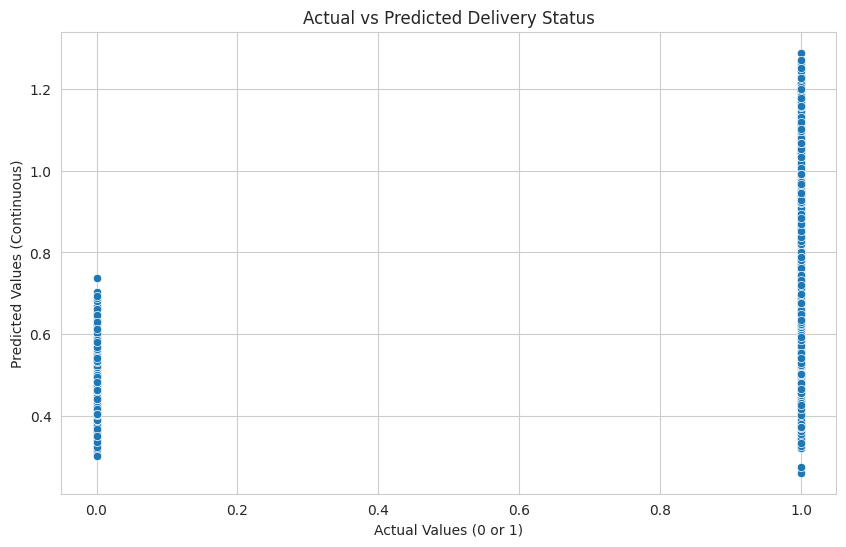


Model Evaluation Metrics:
Mean Absolute Error (MAE): 0.41
Mean Squared Error (MSE): 0.20
R-squared (R²): 0.18
Accuracy: 0.65


In [17]:
# Step 1: Import necessary libraries
import pandas as pd                      # For data manipulation
import matplotlib.pyplot as plt          # For plotting graphs
import seaborn as sns                    # For enhanced visualizations
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.linear_model import LinearRegression      # For building the model
from sklearn import metrics              # For evaluating model performance
# Set a clean visual style for plots
sns.set_style('whitegrid')

# Step 2: Load your dataset
df = pd.read_csv('Train.csv')  # Replace with your actual file path
# Step 3: Preview the dataset
print("First 5 rows of the dataset:")
print(df.head())  # Display the top rows to inspect the structure

# Step 4: Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())  # Ensure data is clean before modeling
# Step 5: Select numerical features for regression
# These are the independent variables (predictors)
features = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
            'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

X = df[features]  # Feature matrix
y = df['Reached.on.Time_Y.N']  # Target variable (binary: 0 or 1)
# Step 6: Split the data into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Step 7: Create and train the linear regression model
model = LinearRegression()         # Instantiate the model
model.fit(X_train, y_train)        # Fit the model to training data


# Step 8: Inspect model parameters
print("\nModel Parameters:")
print(f"Intercept (β₀): {model.intercept_:.2f}")  # y-intercept
print("Coefficients (β₁ to βₙ):")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.2f}")  # Slope for each feature
# Step 9: Make predictions on the test set
y_pred = model.predict(X_test)  # Predict target values
# Step 10: Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.title('Actual vs Predicted Delivery Status')
plt.xlabel('Actual Values (0 or 1)')
plt.ylabel('Predicted Values (Continuous)')
plt.show()
# Step 11: Evaluate model performance
print("\nModel Evaluation Metrics:")
mae = metrics.mean_absolute_error(y_test, y_pred)  # Average absolute error
mse = metrics.mean_squared_error(y_test, y_pred)   # Average squared error
r2 = metrics.r2_score(y_test, y_pred)              # R² score (goodness of fit)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")
# Step 12: Calculate accuracy (by converting continuous predictions to 0 or 1)
y_pred_class = [1 if pred >= 0.5 else 0 for pred in y_pred]

accuracy = metrics.accuracy_score(y_test, y_pred_class)
print(f"Accuracy: {accuracy:.2f}")






First 5 rows of the dataset:
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                

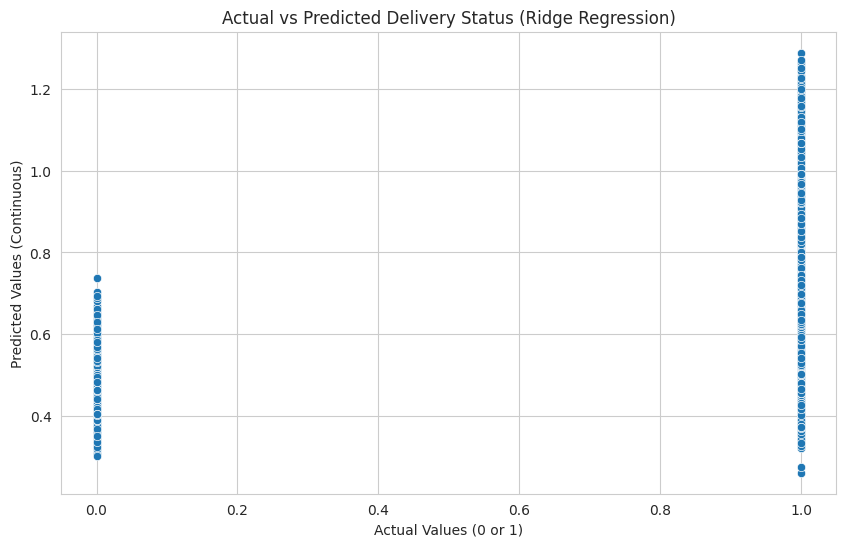


Model Evaluation Metrics:
Mean Absolute Error (MAE): 0.41
Mean Squared Error (MSE): 0.20
R-squared (R²): 0.18
Accuracy: 0.65

Confusion Matrix:
[[498 397]
 [378 927]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.56      0.56       895
           1       0.70      0.71      0.71      1305

    accuracy                           0.65      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.65      0.65      0.65      2200



In [18]:
# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge          # Ridge Regression
from sklearn import metrics

# Set a clean visual style
sns.set_style('whitegrid')

# Step 2: Load dataset
df = pd.read_csv('Train.csv')  # Replace with your actual file path

# Step 3: Preview dataset
print("First 5 rows of the dataset:")
print(df.head())

# Step 4: Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Step 5: Select numerical features
features = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
            'Prior_purchases', 'Discount_offered', 'Weight_in_gms']
X = df[features]
y = df['Reached.on.Time_Y.N']

# Step 6: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Create and train the Ridge regression model
model = Ridge(alpha=1.0)  # You can adjust alpha (regularization strength)
model.fit(X_train, y_train)

# Step 8: Inspect model parameters
print("\nModel Parameters:")
print(f"Intercept (β₀): {model.intercept_:.2f}")
print("Coefficients (β₁ to βₙ):")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.2f}")

# Step 9: Make predictions
y_pred = model.predict(X_test)

# Step 10: Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.title('Actual vs Predicted Delivery Status (Ridge Regression)')
plt.xlabel('Actual Values (0 or 1)')
plt.ylabel('Predicted Values (Continuous)')
plt.show()

# Step 11: Evaluate model performance
print("\nModel Evaluation Metrics:")
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# Step 12: Calculate accuracy (convert continuous predictions to 0/1)
y_pred_class = [1 if pred >= 0.5 else 0 for pred in y_pred]
accuracy = metrics.accuracy_score(y_test, y_pred_class)
print(f"Accuracy: {accuracy:.2f}")

# Step 13 (optional): Confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred_class)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))


First 5 rows:
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                44           12

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:02:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model Evaluation Metrics (XGBoost):
Accuracy: 0.66
MAE: 0.34
MSE: 0.34
R²: -0.42

Confusion Matrix:
[[612 283]
 [472 833]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.68      0.62       895
           1       0.75      0.64      0.69      1305

    accuracy                           0.66      2200
   macro avg       0.66      0.66      0.65      2200
weighted avg       0.67      0.66      0.66      2200



/tmp/ipython-input-3064845385.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model.feature_importances_, y=features, palette='viridis')


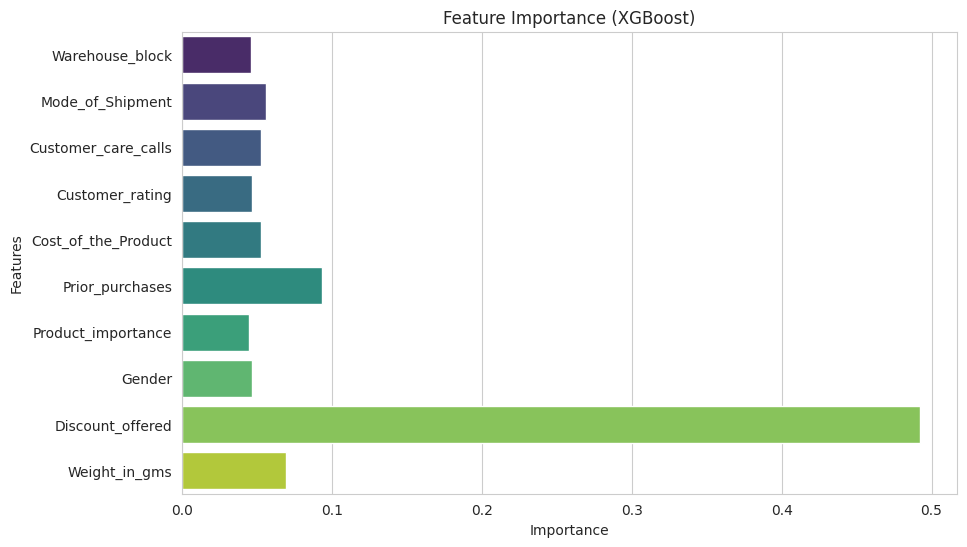

In [19]:
# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Step 2: Load dataset
df = pd.read_csv('Train.csv')  # Replace with your actual file path

# Step 3: Preview data
print("First 5 rows:")
print(df.head())

# Step 4: Check missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Step 5: Encode categorical columns
label_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
encoder = LabelEncoder()

for col in label_cols:
    df[col] = encoder.fit_transform(df[col])

# Step 6: Select features and target
features = ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
            'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
            'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms']

X = df[features]
y = df['Reached.on.Time_Y.N']

# Step 7: Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 8: Create and train the XGBoost model
model = XGBClassifier(
    n_estimators=200,        # Number of trees
    learning_rate=0.1,       # Step size shrinkage
    max_depth=6,             # Maximum depth of each tree
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'    # Prevents warning
)

model.fit(X_train, y_train)

# Step 9: Make predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # For probability output

# Step 10: Evaluate model performance
accuracy = metrics.accuracy_score(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics (XGBoost):")
print(f"Accuracy: {accuracy:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

# Step 11: Confusion matrix & classification report
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 12: Feature importance visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=model.feature_importances_, y=features, palette='viridis')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:05:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Accuracy: 0.664

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.74      0.64       895
           1       0.77      0.61      0.68      1305

    accuracy                           0.66      2200
   macro avg       0.67      0.68      0.66      2200
weighted avg       0.69      0.66      0.67      2200



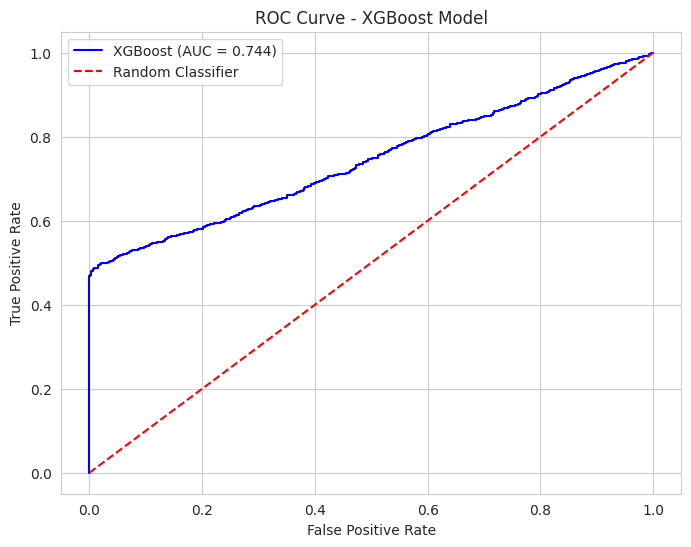

AUC Score: 0.744


In [21]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# Step 2: Load dataset
df = pd.read_csv('Train.csv')  # Replace with your actual file path

# Step 3: Encode categorical columns
label_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
encoder = LabelEncoder()
for col in label_cols:
    df[col] = encoder.fit_transform(df[col])

# Step 4: Feature selection
features = ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
            'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
            'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms']
X = df[features]
y = df['Reached.on.Time_Y.N']

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Scale features (optional)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: XGBoost model
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# Step 8: Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC

# Step 9: Evaluation metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 10: ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'XGBoost (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.title('ROC Curve - XGBoost Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.3f}")
